# ZeRO-1 / ZeRO-2 / ZeRO-3 on 32 virtual GPUs

**Goal.** Build 32 *virtual GPUs* out of CPU threads, train one demo model on them four different ways
(plain data parallel, ZeRO-1, ZeRO-2, ZeRO-3), and *measure* — not just read about — how memory and
communication change at each stage.

Everything is pure NumPy. There is no GPU and no `torch.distributed`; the collectives (reduce-scatter,
all-gather, all-reduce, broadcast) are implemented as ring algorithms so every byte on the wire is counted,
and every virtual GPU has a memory ledger so every byte in "HBM" is counted too.

The one-sentence thesis of this notebook:

> Large-model training is not just a compute problem. It is a **memory-placement + communication +
> synchronization + economics** problem, and ZeRO/FSDP exist to trade extra communication for much lower
> per-GPU memory.

| Section | What we measure |
|---|---|
| 1 | The cluster: 32 ranks, 4 nodes × 8, and the memory ledger |
| 2 | Collectives, and the identity `all-reduce = reduce-scatter + all-gather` |
| 3 | The demo model and its 16 bytes/parameter memory stack |
| 4 | Train with DP, ZeRO-1, ZeRO-2, ZeRO-3 — prove the math is identical |
| 5 | **Memory**: peak per GPU by category, and the within-step timeline |
| 6 | **Communication**: bytes per rank per step by collective |
| 7 | **Computation & time**: real wall-clock, modelled H100 step time, stragglers |
| 8 | Scaling the formulas to 7B–405B models: what fits on 32×80 GB and what it costs |
| 9 | How this maps onto what real labs run (DeepSpeed, FSDP, HSDP, 3D parallelism) |

In [1]:
import sys, time
sys.path.insert(0, ".")           # run from the repo root
import numpy as np
import matplotlib.pyplot as plt
from zero_sim import *
from zero_sim.analytic import PARAM_BYTES, GRAD_BYTES, OPTIM_BYTES

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
STAGES = ["DP", "ZeRO-1", "ZeRO-2", "ZeRO-3"]
COLORS = dict(zip(STAGES, ["#555555", "#1f77b4", "#ff7f0e", "#d62728"]))
CAT_COLORS = {"params": "#4c72b0", "grads": "#dd8452", "master": "#55a868", "optim": "#8172b3", "activations": "#c44e52", "temp": "#937860"}
np.set_printoptions(precision=3, suppress=True)

## 1. The cluster: 32 virtual GPUs

A `VirtualGPU` is a rank with a **memory ledger** (bytes resident per category, plus high-water marks), a
**storage dict** (the NumPy arrays that "live in its HBM"), and its own **thread** in a 32-worker pool so the
ranks' forward/backward passes really run concurrently.

The 32 ranks are arranged as **4 nodes × 8 GPUs**, because the central topology point is that a
collective inside one NVSwitch domain is a very different operation from one spanning hosts. The
`HardwareProfile` below encodes that asymmetry (numbers are H100-class order-of-magnitude; only the ratios matter).

In [2]:
cluster = Cluster(world_size=32, gpus_per_node=8)
hw = cluster.hw
print(f"{cluster.N} virtual GPUs over {cluster.N // cluster.gpus_per_node} nodes")
for node in range(cluster.N // cluster.gpus_per_node):
    print(f"  node {node}: ranks", [g.rank for g in cluster.gpus if g.node == node])
print()
print("Hardware cost model :", hw.name)
print(f"  intra-node bandwidth : {hw.intra_node_bw/1e9:6.0f} GB/s   latency {hw.intra_latency*1e6:.0f} µs")
print(f"  inter-node bandwidth : {hw.inter_node_bw/1e9:6.0f} GB/s   latency {hw.inter_latency*1e6:.0f} µs   (≈{hw.intra_node_bw/hw.inter_node_bw:.0f}× slower)")
print(f"  peak BF16 FLOP/s     : {hw.peak_flops/1e12:.0f} TFLOP/s, assumed MFU {hw.mfu:.0%}")
print(f"  HBM per GPU          : {fmt_bytes(hw.hbm_bytes)}")

32 virtual GPUs over 4 nodes
  node 0: ranks [0, 1, 2, 3, 4, 5, 6, 7]
  node 1: ranks [8, 9, 10, 11, 12, 13, 14, 15]
  node 2: ranks [16, 17, 18, 19, 20, 21, 22, 23]
  node 3: ranks [24, 25, 26, 27, 28, 29, 30, 31]

Hardware cost model : H100-like, 8 GPU/node, 400Gb/s IB
  intra-node bandwidth :    450 GB/s   latency 5 µs
  inter-node bandwidth :     50 GB/s   latency 20 µs   (≈9× slower)
  peak BF16 FLOP/s     : 989 TFLOP/s, assumed MFU 40%
  HBM per GPU          : 80.0 GB


## 2. Collectives — the distributed-systems vocabulary

Collectives are the "distributed primitives for tensors". Two of them do all the work in ZeRO:

* **reduce-scatter**: everyone contributes a full vector; rank *r* ends up with **only chunk *r* of the sum**.
* **all-gather**: everyone contributes a chunk; everyone ends up with the **whole** concatenation.

and the key identity: **all-reduce = reduce-scatter + all-gather**. In the ring implementation each of them costs
each rank `(N−1)/N × size` bytes on the wire, so all-reduce costs `2(N−1)/N × size` — *independent of N* for
large N. That is why data parallelism's gradient sync is "cheap per GPU" but is still a full 2Ψ of traffic per step.

Let's watch the ring do it on tiny arrays and count the bytes.

In [3]:
demo = Cluster(world_size=4, gpus_per_node=4)   # tiny world so we can eyeball it
N = demo.N
vectors = [np.full(8, r + 1, dtype=np.float32) for r in range(N)]   # rank r holds all (r+1)s
print("inputs (one row per rank):\n", np.stack(vectors))

shards = demo.reduce_scatter(vectors)
print("\nafter reduce-scatter, rank r holds chunk r of the SUM (1+2+3+4 = 10):")
for r, s in enumerate(shards): print(f"  rank {r}: {s}")

gathered = demo.all_gather(shards)
print("\nafter all-gather every rank holds the full reduced vector:")
print("  rank 0:", gathered[0], "  (identical on all ranks:", all(np.array_equal(gathered[0], g) for g in gathered), ")")

print("\nbytes each rank put on the wire (2 bytes/element, ring algorithm):")
for rec in demo.comm.records:
    print(f"  {rec.collective:15s} {rec.bytes_per_rank:4d} B  = (N-1)/N * {vectors[0].nbytes//2} elements * 2 B")

inputs (one row per rank):
 [[1. 1. 1. 1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3. 3. 3. 3.]
 [4. 4. 4. 4. 4. 4. 4. 4.]]

after reduce-scatter, rank r holds chunk r of the SUM (1+2+3+4 = 10):
  rank 0: [10. 10.]
  rank 1: [10. 10.]
  rank 2: [10. 10.]
  rank 3: [10. 10.]

after all-gather every rank holds the full reduced vector:
  rank 0: [10. 10. 10. 10. 10. 10. 10. 10.]   (identical on all ranks: True )

bytes each rank put on the wire (2 bytes/element, ring algorithm):
  reduce_scatter    12 B  = (N-1)/N * 16 elements * 2 B
  all_gather        12 B  = (N-1)/N * 16 elements * 2 B


Why not a single "coordinator GPU" that receives every gradient, averages, and sends back? The answer
is the same instinct as in distributed databases: it creates a hotspot and idles everyone else. Below is the
per-rank traffic for a parameter-server style sync versus the ring as N grows — the ring is flat, the
coordinator's inbound link scales with N.

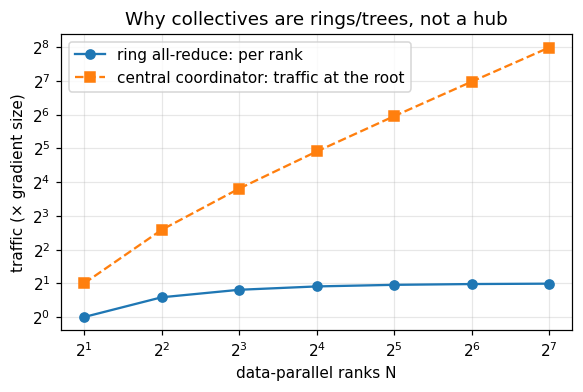

In [4]:
Ns = np.array([2, 4, 8, 16, 32, 64, 128])
size = 1.0  # in units of "one full gradient"
ring = 2 * (Ns - 1) / Ns * size
coordinator_root = (Ns - 1) * size * 2       # receives N-1 grads, sends N-1 results
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(Ns, ring, "o-", label="ring all-reduce: per rank")
ax.plot(Ns, coordinator_root, "s--", label="central coordinator: traffic at the root")
ax.set_xscale("log", base=2); ax.set_yscale("log", base=2)
ax.set_xlabel("data-parallel ranks N"); ax.set_ylabel("traffic (× gradient size)")
ax.set_title("Why collectives are rings/trees, not a hub"); ax.legend(); plt.show()

## 3. The demo model and its memory stack

A 5-layer MLP classifier (~3.4 M parameters) with **hand-written forward/backward** — no autograd — because
ZeRO-3 needs to gather a layer's weights right before they are used and free them right after, and that is
much clearer when the per-layer compute is explicit.

Storage follows the DeepSpeed/FSDP convention: one **flat buffer per layer**, padded to a multiple of 32, so
rank *r* owns chunk *r* of every layer. Mixed precision means the *working* weights and gradients are 16-bit
(NumPy `float16` stands in for `bfloat16`) and the optimizer keeps fp32 master weights plus Adam's `m` and `v`.

That gives the classic **16 bytes per parameter** memory stack:

In [5]:
SIZES = [256, 1024, 1024, 1024, 1024, 10]
model = MLP(SIZES, world_size=32)
psi = model.n_padded
print(f"layers: {SIZES}")
print(f"Ψ = {model.n_params:,} parameters ({psi:,} after padding each layer to a multiple of 32)")
print(f"rank r owns chunk r of every layer -> per-rank chunk sizes:", [l.chunk for l in model.layers])
print()
rows = [("working weights (bf16)", PARAM_BYTES), ("gradients (bf16)", GRAD_BYTES),
        ("fp32 master weights", 4), ("Adam m (fp32)", 4), ("Adam v (fp32)", 4)]
print(f"{'state':26s} {'bytes/param':>11s} {'for this model':>16s}")
for name, b in rows:
    print(f"{name:26s} {b:>11d} {fmt_bytes(b*psi):>16s}")
print(f"{'TOTAL model state':26s} {sum(b for _,b in rows):>11d} {fmt_bytes(16*psi):>16s}   <- replicated on EVERY GPU in plain DP")

layers: [256, 1024, 1024, 1024, 1024, 10]
Ψ = 3,422,218 parameters (3,422,240 after padding each layer to a multiple of 32)
rank r owns chunk r of every layer -> per-rank chunk sizes: [8224, 32800, 32800, 32800, 321]

state                      bytes/param   for this model
working weights (bf16)               2           6.5 MB
gradients (bf16)                     2           6.5 MB
fp32 master weights                  4          13.1 MB
Adam m (fp32)                        4          13.1 MB
Adam v (fp32)                        4          13.1 MB
TOTAL model state                   16          52.2 MB   <- replicated on EVERY GPU in plain DP


## 4. Train it four ways

Same model, same data, same seed, same optimizer. The only thing that changes between the four trainers is
**where bytes live and which collective moves them**:

| | params | grads | optimizer (master + m + v) | sync pattern |
|---|---|---|---|---|
| **DP** | replicated | replicated | replicated | all-reduce(grads) |
| **ZeRO-1** | replicated | replicated | **sharded** | reduce-scatter(grads) → update my shard → all-gather(params) |
| **ZeRO-2** | replicated | **sharded** | sharded | per-layer reduce-scatter *during* backward → update → all-gather(params) |
| **ZeRO-3** | **sharded** | sharded | sharded | all-gather(layer) just-in-time in fwd *and* bwd, reduce-scatter(grad) per layer |

Each rank gets a different micro-batch of 32 samples, so the **global batch is 32 × 32 = 1024**
(`global batch = micro-batch × DP ranks × grad-accumulation steps`; accumulation = 1 here).

In [6]:
MICRO_BATCH, STEPS = 32, 12
X, y = make_dataset(32 * MICRO_BATCH * STEPS, SIZES[0], SIZES[-1], seed=1)

results, trainers, clusters = {}, {}, {}
for stage in STAGES:
    c = Cluster(32, 8)
    tr = TRAINERS[stage](c, model, AdamConfig(lr=2e-3), seed=0)
    tr.setup()
    stats = []
    for s in range(STEPS):
        i = s * 32 * MICRO_BATCH
        stats.append(tr.step(X[i:i + 32 * MICRO_BATCH], y[i:i + 32 * MICRO_BATCH]))
    results[stage], trainers[stage], clusters[stage] = stats, tr, c
    print(f"{stage:7s} final loss {stats[-1].loss:.4f}   mean wall/step {np.mean([s.wall_seconds for s in stats]):.2f}s   "
          f"peak/GPU {fmt_bytes(stats[-1].peak_bytes_per_gpu):>9s}   comm/rank/step {fmt_bytes(stats[-1].comm_bytes_per_rank):>8s}")

DP      final loss 2.2602   mean wall/step 1.36s   peak/GPU   52.2 MB   comm/rank/step  12.6 MB


ZeRO-1  final loss 2.2602   mean wall/step 0.79s   peak/GPU   14.3 MB   comm/rank/step  12.6 MB


ZeRO-2  final loss 2.2602   mean wall/step 0.82s   peak/GPU   10.0 MB   comm/rank/step  12.6 MB


ZeRO-3  final loss 2.2602   mean wall/step 0.82s   peak/GPU    5.7 MB   comm/rank/step  19.0 MB


### Sharding must not change the math

If ZeRO is implemented correctly it is invisible to the optimizer: the weights after every step must be
identical to plain DP. We check it **bitwise**.

DP      max |Δweight| vs DP after 12 steps = 0.0   identical: True
ZeRO-1  max |Δweight| vs DP after 12 steps = 0.0   identical: True
ZeRO-2  max |Δweight| vs DP after 12 steps = 0.0   identical: True
ZeRO-3  max |Δweight| vs DP after 12 steps = 0.0   identical: True


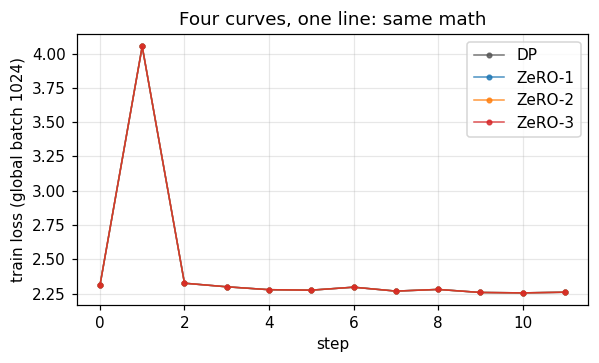

In [7]:
ref = trainers["DP"].full_params()
for stage in STAGES:
    diffs = [float(np.abs(a.astype(np.float32) - b.astype(np.float32)).max()) for a, b in zip(ref, trainers[stage].full_params())]
    print(f"{stage:7s} max |Δweight| vs DP after {STEPS} steps = {max(diffs)}   identical: {max(diffs) == 0.0}")

fig, ax = plt.subplots(figsize=(6, 3.2))
for stage in STAGES:
    ax.plot([s.loss for s in results[stage]], marker="o", ms=3, lw=1, color=COLORS[stage], label=stage, alpha=0.8)
ax.set_xlabel("step"); ax.set_ylabel("train loss (global batch 1024)"); ax.set_title("Four curves, one line: same math"); ax.legend(); plt.show()

## 5. Memory: what actually sits on each GPU

Now the interesting part. The ledger recorded, for every rank, the peak bytes in each category during a step.
The ZeRO paper's formulas for **persistent model state** per GPU with N = 32 are:

* DP: `(2 + 2 + 12) Ψ = 16 Ψ`
* ZeRO-1: `(2 + 2) Ψ + 12 Ψ / N`
* ZeRO-2: `2 Ψ + (2 + 12) Ψ / N`
* ZeRO-3: `16 Ψ / N`

The simulator should reproduce these exactly, *plus* whatever transient buffers each stage needs at its peak.

stage          params        grads       master        optim  activations         temp         PEAK      theory*   vs DP
DP             6.5 MB       6.5 MB      13.1 MB      26.1 MB     400.0 KB        0.0 B      52.2 MB      52.2 MB    1.0×
ZeRO-1         6.5 MB       6.5 MB     417.8 KB     835.5 KB     400.0 KB        0.0 B      14.3 MB      14.3 MB    3.7×
ZeRO-2         6.5 MB       2.1 MB     417.8 KB     835.5 KB     400.0 KB        0.0 B      10.0 MB       8.0 MB    5.2×
ZeRO-3       208.9 KB       2.1 MB     417.8 KB     835.5 KB     400.0 KB       2.0 MB       5.7 MB       1.6 MB    9.2×
* theory = persistent model state only (params+grads+optimizer); the simulator additionally sees activations and transient buffers


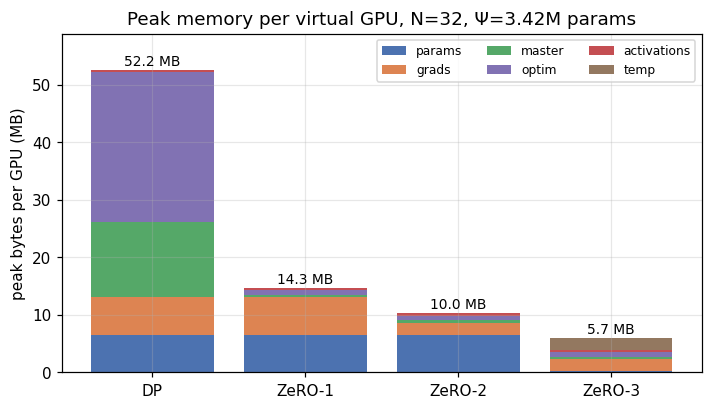

In [8]:
last = {s: results[s][-1] for s in STAGES}
cats = ["params", "grads", "master", "optim", "activations", "temp"]

print(f"{'stage':8s}" + "".join(f"{c:>13s}" for c in cats) + f"{'PEAK':>13s}{'theory*':>13s}{'vs DP':>8s}")
for s in STAGES:
    est = model_state_bytes(psi, 32, s).total
    print(f"{s:8s}" + "".join(f"{fmt_bytes(last[s].peak_by_cat[c]):>13s}" for c in cats)
          + f"{fmt_bytes(last[s].peak_bytes_per_gpu):>13s}{fmt_bytes(est):>13s}{last['DP'].peak_bytes_per_gpu/last[s].peak_bytes_per_gpu:>7.1f}×")
print("* theory = persistent model state only (params+grads+optimizer); the simulator additionally sees activations and transient buffers")

fig, ax = plt.subplots(figsize=(7.5, 4))
bottom = np.zeros(len(STAGES))
for c in cats:
    vals = np.array([last[s].peak_by_cat[c] for s in STAGES]) / 2**20
    ax.bar(STAGES, vals, bottom=bottom, label=c, color=CAT_COLORS[c]); bottom += vals
for i, s in enumerate(STAGES):
    ax.text(i, bottom[i] + 0.8, fmt_bytes(last[s].peak_bytes_per_gpu), ha="center", fontsize=9)
ax.set_ylim(0, bottom.max() * 1.12); ax.set_ylabel("peak bytes per GPU (MB)"); ax.set_title(f"Peak memory per virtual GPU, N=32, Ψ={psi/1e6:.2f}M params")
ax.legend(ncol=3, fontsize=8); plt.show()

Reading the bars:

* **DP → ZeRO-1** removes the biggest block. Optimizer state (fp32 master + m + v) is 12 of the 16 bytes/param, so
  sharding *only that* already cuts per-GPU memory ~3.7×. This is why ZeRO-1 is the "free lunch" stage: same communication
  volume as DP (we'll verify), big memory win.
* **ZeRO-1 → ZeRO-2** trims gradients from 2Ψ to 2Ψ/N — but note the `grads` bar is not zero: at the peak, *one layer's*
  gradient bucket exists in full while it waits to be reduce-scattered. Bucket size is a real tuning knob.
* **ZeRO-2 → ZeRO-3** shards the working weights too. The `params` bar is now tiny, and a new `temp` bar appears: the
  one layer that is fully gathered at that instant. Peak ≈ `16Ψ/N + one layer` — which is why ZeRO-3 memory is bounded by
  the *largest layer*, not the model.
* **Activations are identical in all four**. ZeRO shards *model state*, not activations. Activation memory scales with
  micro-batch × sequence × width × depth and needs different tools (activation checkpointing, sequence/context parallelism).

### Within-step memory timeline

Peaks hide the choreography. The ledger also snapshotted every rank at each phase boundary — here is rank 0 during the
last step, stacked by category. Watch ZeRO-2's per-layer sawtooth in backward, and ZeRO-3's gather/release in *both*
directions.

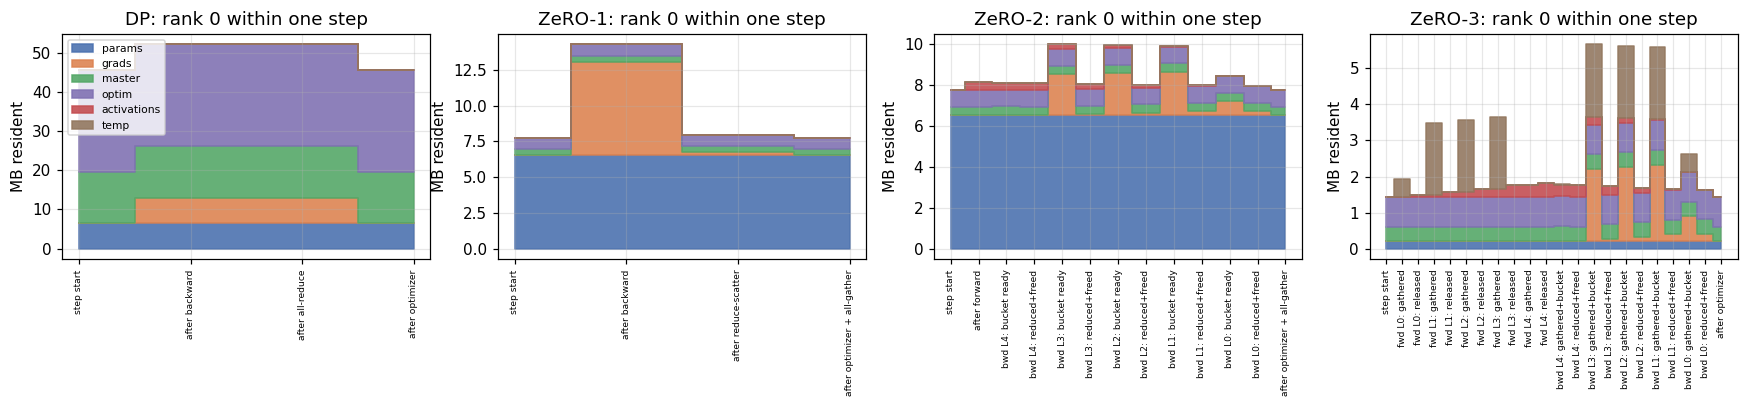

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=False)
for ax, s in zip(axes, STAGES):
    tl = clusters[s].gpus[0].mem.timeline
    labels = [t[0] for t in tl]
    xs = np.arange(len(tl))
    bottom = np.zeros(len(tl))
    for c in cats:
        v = np.array([t[1][c] for t in tl]) / 2**20
        ax.fill_between(xs, bottom, bottom + v, step="mid", color=CAT_COLORS[c], label=c, alpha=0.9); bottom += v
    ax.set_title(f"{s}: rank 0 within one step"); ax.set_ylabel("MB resident")
    ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=90, fontsize=6)
axes[0].legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()

## 6. Communication: the price of the memory

Every collective was logged with the bytes each rank moved (2 bytes/element on the wire, ring algorithm, so each
reduce-scatter or all-gather moves `(N−1)/N × size` per rank). The ZeRO paper's claim is:

* DP, ZeRO-1, ZeRO-2 all move **2Ψ** per step (DP: one all-reduce; ZeRO-1/2: one reduce-scatter + one all-gather).
* ZeRO-3 moves **3Ψ** — 1.5× — because parameters are all-gathered twice (forward *and* backward) plus one gradient reduce-scatter.

stage     reduce_scatter  all_gather  #collectives  TOTAL/rank/step    theory  × DP
DP                6.3 MB      6.3 MB            10          12.6 MB   12.6 MB 1.00×
ZeRO-1            6.3 MB      6.3 MB            10          12.6 MB   12.6 MB 1.00×
ZeRO-2            6.3 MB      6.3 MB            10          12.6 MB   12.6 MB 1.00×
ZeRO-3            6.3 MB     12.6 MB            15          19.0 MB   19.0 MB 1.50×


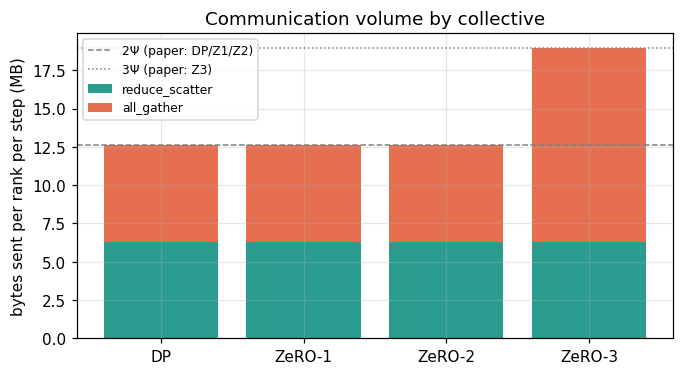

In [10]:
print(f"{'stage':8s}{'reduce_scatter':>16s}{'all_gather':>12s}{'#collectives':>14s}{'TOTAL/rank/step':>17s}{'theory':>10s}{'× DP':>6s}")
for s in STAGES:
    c = clusters[s]; step = results[s][-1].step
    by = c.comm.by_collective(step); n = sum(1 for r in c.comm.records if r.step == step)
    tot = results[s][-1].comm_bytes_per_rank
    print(f"{s:8s}{fmt_bytes(by.get('reduce_scatter',0)):>16s}{fmt_bytes(by.get('all_gather',0)):>12s}{n:>14d}{fmt_bytes(tot):>17s}"
          f"{fmt_bytes(comm_volume_bytes(psi,32,s)):>10s}{tot/results['DP'][-1].comm_bytes_per_rank:>5.2f}×")

fig, ax = plt.subplots(figsize=(7, 3.6))
bottom = np.zeros(len(STAGES))
for coll, col in [("reduce_scatter", "#2a9d8f"), ("all_gather", "#e76f51")]:
    v = np.array([clusters[s].comm.by_collective(results[s][-1].step).get(coll, 0) for s in STAGES]) / 2**20
    ax.bar(STAGES, v, bottom=bottom, label=coll, color=col); bottom += v
ax.axhline(2 * psi * 31/32 * 2 / 2**20, ls="--", color="gray", lw=1, label="2Ψ (paper: DP/Z1/Z2)")
ax.axhline(3 * psi * 31/32 * 2 / 2**20, ls=":", color="gray", lw=1, label="3Ψ (paper: Z3)")
ax.set_ylabel("bytes sent per rank per step (MB)"); ax.set_title("Communication volume by collective"); ax.legend(fontsize=8); plt.show()

Two things worth noticing that the summary tables usually skip:

1. **ZeRO-2 is not "more communication" than ZeRO-1** — same 2Ψ. What changes is *when* it happens: ZeRO-2 issues one
   reduce-scatter per layer bucket *during* backward, which is exactly what lets it overlap communication with the
   remaining backward compute. The number of collectives goes up (one per bucket), the bytes do not.
2. **ZeRO-3's extra 1Ψ is the forward all-gather.** In a real system this is what shows up on the critical path: layer
   *l+1* cannot start until its weights arrive, so frameworks prefetch the next layer's all-gather while computing the
   current one. When they can't hide it, ZeRO-3 makes the model *fit* — it does not make training fastest.

## 7. Computation and time

### 7a. Real wall-clock on the CPU threads
The virtual GPUs genuinely ran concurrently. The measured step time includes the host-side collectives (which are
serial Python loops here, so treat the absolute numbers as illustrative). What is meaningful: **ZeRO-3 does the same
FLOPs as DP** — sharding parameter *storage* does not shard compute; every rank still runs the whole forward and backward
on its own micro-batch.

One thing *is* replicated in DP that ZeRO removes: the **optimizer step**. In DP all 32 ranks run Adam over all Ψ
parameters (identical, redundant work); from ZeRO-1 on each rank updates only its Ψ/N shard. It shows up below as
the larger "thread compute" for DP — the FLOP counter only tracks matmuls, so it doesn't see it.

In [11]:
print(f"{'stage':8s}{'wall/step (s)':>15s}{'FLOPs/rank/step':>18s}{'thread compute (s)':>20s}")
for s in STAGES:
    c = clusters[s]
    print(f"{s:8s}{np.mean([r.wall_seconds for r in results[s]]):>15.2f}{max(g.flops for g in c.gpus):>18.3e}{c.wall_compute_seconds():>20.3f}")

stage     wall/step (s)   FLOPs/rank/step  thread compute (s)
DP                 1.36         6.563e+08               0.420
ZeRO-1             0.79         6.563e+08               0.197
ZeRO-2             0.82         6.563e+08               0.180
ZeRO-3             0.82         6.563e+08               0.163


### 7b. Modelled step time on real hardware

Using the `HardwareProfile` (H100-class compute at 40% MFU, 450 GB/s inside a node, 50 GB/s between nodes), the cost
model turns FLOPs and ring-collective bytes into seconds. For our 3.4M-parameter toy on 32 GPUs the result is
extreme — and instructive:

In [12]:
print(f"{'stage':8s}{'compute (ms)':>13s}{'comm (ms)':>11s}{'comm share':>12s}")
for s in STAGES:
    st = results[s][-1]
    print(f"{s:8s}{st.compute_sim_seconds*1e3:>13.4f}{st.comm_sim_seconds*1e3:>11.2f}{st.comm_sim_seconds/(st.comm_sim_seconds+st.compute_sim_seconds):>11.1%}")
print("\nA tiny model on 32 fast GPUs is ~100% communication-bound: the old rule that")
print("'faster GPUs make networking look worse' taken to the limit. Sharding a model that fits on one GPU is pure overhead.")

stage    compute (ms)  comm (ms)  comm share
DP             0.0017       6.47     100.0%
ZeRO-1         0.0017       6.47     100.0%
ZeRO-2         0.0017       6.47     100.0%
ZeRO-3         0.0017       9.70     100.0%

A tiny model on 32 fast GPUs is ~100% communication-bound: the old rule that
'faster GPUs make networking look worse' taken to the limit. Sharding a model that fits on one GPU is pure overhead.


### 7c. A synchronous step runs at the pace of its slowest rank

Stragglers (thermal throttling, a congested NIC, a noisy neighbour) are real production failure
modes. Because every collective is a barrier, one slow rank stalls all 32. Let's slow down rank 17 by a full second in the forward pass and measure.

In [13]:
c = Cluster(32, 8); tr = ZeRO2Trainer(c, model, AdamConfig(lr=2e-3)); tr.setup()
base = np.mean([tr.step(X[:32*MICRO_BATCH], y[:32*MICRO_BATCH]).wall_seconds for _ in range(3)])

orig = tr._forward_layer
def slow_forward(gpu, l, flat, x):
    if gpu.rank == 17 and l == 0:
        time.sleep(1.0)           # one thermally-throttled GPU
    return orig(gpu, l, flat, x)
tr._forward_layer = slow_forward
slow = np.mean([tr.step(X[:32*MICRO_BATCH], y[:32*MICRO_BATCH]).wall_seconds for _ in range(3)])
busiest = max(g.compute_seconds for g in c.gpus); median = float(np.median([g.compute_seconds for g in c.gpus]))
print(f"step time, all ranks healthy : {base:.3f} s")
print(f"step time, rank 17 slow      : {slow:.3f} s   (+{slow-base:.3f} s ≈ the injected 1.0 s)")
print(f"per-rank compute this step   : median {median:.3f} s, rank 17 {busiest:.3f} s -> 31 GPUs idled waiting for one")

step time, all ranks healthy : 1.037 s
step time, rank 17 slow      : 1.878 s   (+0.841 s ≈ the injected 1.0 s)
per-rank compute this step   : median 0.129 s, rank 17 1.107 s -> 31 GPUs idled waiting for one


## 8. Scaling the formulas to real models on 32 × 80 GB

The toy proved the simulator matches the ZeRO paper's formulas exactly. Now apply those same formulas to the sizes
labs actually train, on our 32-GPU / 4-node topology with 80 GB HBM. The decision framework is simple:
*estimate memory, then choose the lowest sharding stage that fits with headroom*.

Activations are estimated with the standard transformer rule of thumb (`≈34·s·b·h` bytes per layer without
checkpointing, `2·s·b·h` with full checkpointing) for micro-batch 1, sequence 4096. Real activation memory depends on
the attention implementation, so treat that column as order-of-magnitude.

In [14]:
MODELS = {  # params, hidden, layers   (rounded public configs)
    "1B":   (1.0e9, 2048, 24), "7B":  (7.0e9, 4096, 32), "13B": (13.0e9, 5120, 40),
    "70B": (70.0e9, 8192, 80), "405B": (405e9, 16384, 126),
}
HBM = hw.hbm_bytes; N32 = 32; SEQ = 4096
acts = {m: activation_bytes_transformer(1, SEQ, h, L, checkpointing=True) for m, (p, h, L) in MODELS.items()}
print(f"{'model':6s}{'act/GPU*':>10s} | " + " | ".join(f"{s:^16s}" for s in STAGES))
print("-" * 90)
fit = {}
for m, (p, h, L) in MODELS.items():
    row = []
    for s in STAGES:
        need = model_state_bytes(p, N32, s).total + acts[m]
        ok = need < 0.85 * HBM      # keep 15% headroom for temp buffers / fragmentation
        fit[(m, s)] = ok
        row.append(f"{fmt_bytes(need):>10s} {'✓' if ok else '✗'} ")
    print(f"{m:6s}{fmt_bytes(acts[m]):>10s} | " + " | ".join(f"{r:^16s}" for r in row))
print("* micro-batch 1, seq 4096, full activation checkpointing;  ✓ = fits in 80 GB with 15% headroom")

model   act/GPU* |        DP        |      ZeRO-1      |      ZeRO-2      |      ZeRO-3     
------------------------------------------------------------------------------------------
1B      384.0 MB |     15.3 GB ✓    |      4.4 GB ✓    |      2.6 GB ✓    |    860.8 MB ✓   
7B        1.0 GB |    105.3 GB ✗    |     29.5 GB ✓    |     16.9 GB ✓    |      4.3 GB ✓   
13B       1.6 GB |    195.3 GB ✗    |     54.5 GB ✓    |     31.1 GB ✓    |      7.6 GB ✓   
70B       5.0 GB |      1.0 TB ✗    |    290.2 GB ✗    |    163.9 GB ✗    |     37.6 GB ✓   
405B     15.8 GB |      5.9 TB ✗    |      1.6 TB ✗    |    935.1 GB ✗    |    204.3 GB ✗   
* micro-batch 1, seq 4096, full activation checkpointing;  ✓ = fits in 80 GB with 15% headroom


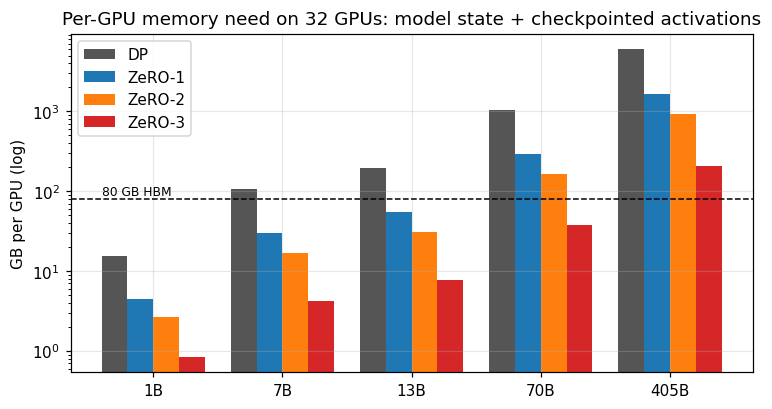

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(MODELS)); w = 0.2
for i, s in enumerate(STAGES):
    vals = [(model_state_bytes(p, N32, s).total + acts[m]) / 2**30 for m, (p, h, L) in MODELS.items()]
    ax.bar(x + (i - 1.5) * w, vals, w, label=s, color=COLORS[s])
ax.axhline(HBM / 2**30, color="k", ls="--", lw=1); ax.text(-0.4, HBM/2**30*1.1, "80 GB HBM", fontsize=8)
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(MODELS.keys())
ax.set_ylabel("GB per GPU (log)"); ax.set_title("Per-GPU memory need on 32 GPUs: model state + checkpointed activations"); ax.legend(); plt.show()

So on this cluster, ZeRO-1 is already enough for 7B and 13B (ZeRO-2 buys headroom for larger micro-batches), while 70B
needs ZeRO-3 — and even then activation checkpointing. 405B does not fit on 32 GPUs at any stage — that is what the other parallelism dimensions
(tensor, pipeline, expert) plus thousands more GPUs are for.

### What does the memory saving cost in time?

Modelled step time = compute (6·Ψ·tokens / (peak·MFU)) + *exposed* communication (ring collectives over the slower
inter-node link, since 32 ranks span 4 nodes). Two knobs matter and are shown: **gradient accumulation** (more
tokens per sync) and **overlap** (how much of the communication hides behind compute).

In [16]:
def step_model(psi, tokens_per_rank, stage, bw, overlap=0.0, lat=hw.inter_latency, N=N32):
    compute = 6 * psi * tokens_per_rank / (hw.peak_flops * hw.mfu)
    per_coll = 2 * psi * (N - 1) / N          # bytes per rank for one RS or AG, bf16 on the wire
    ncoll = {"DP": 2, "ZeRO-1": 2, "ZeRO-2": 2, "ZeRO-3": 3}[stage]
    comm = ncoll * (per_coll / bw + (N - 1) * lat)
    exposed = comm * (1 - overlap)
    return compute, comm, compute / (compute + exposed)

psi7 = MODELS["7B"][0]
print("7B model, 32 GPUs, micro-batch 1 × seq 4096 per rank, inter-node ring (50 GB/s)")
print(f"{'stage':8s}{'compute (ms)':>13s}{'comm (ms)':>11s}{'eff, no overlap':>17s}{'eff, 75% overlap':>18s}{'eff, accum×8':>14s}")
for s in STAGES:
    c0, m0, e0 = step_model(psi7, SEQ, s, hw.inter_node_bw)
    _, _, e1 = step_model(psi7, SEQ, s, hw.inter_node_bw, overlap=0.75)
    _, _, e2 = step_model(psi7, SEQ * 8, s, hw.inter_node_bw)
    print(f"{s:8s}{c0*1e3:>13.0f}{m0*1e3:>11.0f}{e0:>17.1%}{e1:>18.1%}{e2:>14.1%}")

7B model, 32 GPUs, micro-batch 1 × seq 4096 per rank, inter-node ring (50 GB/s)
stage    compute (ms)  comm (ms)  eff, no overlap  eff, 75% overlap  eff, accum×8
DP                435        544            44.4%             76.2%         86.5%
ZeRO-1            435        544            44.4%             76.2%         86.5%
ZeRO-2            435        544            44.4%             76.2%         86.5%
ZeRO-3            435        816            34.8%             68.1%         81.0%


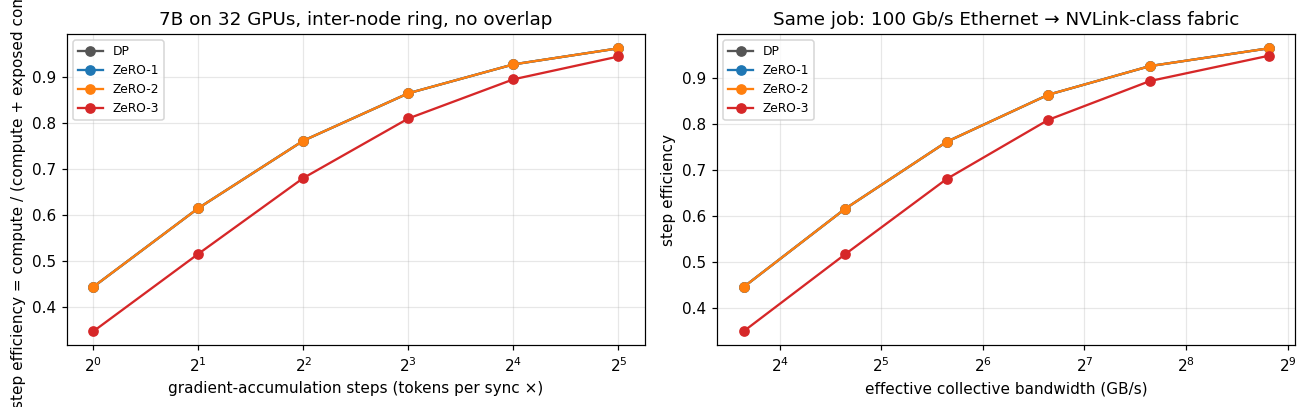

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
accum = np.array([1, 2, 4, 8, 16, 32])
for s in STAGES:
    axes[0].plot(accum, [step_model(psi7, SEQ * a, s, hw.inter_node_bw)[2] for a in accum], "o-", color=COLORS[s], label=s)
axes[0].set_xscale("log", base=2); axes[0].set_xlabel("gradient-accumulation steps (tokens per sync ×)"); axes[0].set_ylabel("step efficiency = compute / (compute + exposed comm)")
axes[0].set_title("7B on 32 GPUs, inter-node ring, no overlap"); axes[0].legend(fontsize=8)

bws = np.array([12.5, 25, 50, 100, 200, 450]) * 1e9
for s in STAGES:
    axes[1].plot(bws / 1e9, [step_model(psi7, SEQ * 4, s, b)[2] for b in bws], "o-", color=COLORS[s], label=s)
axes[1].set_xscale("log", base=2); axes[1].set_xlabel("effective collective bandwidth (GB/s)"); axes[1].set_ylabel("step efficiency")
axes[1].set_title("Same job: 100 Gb/s Ethernet → NVLink-class fabric"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

The shape of these curves is the whole economics argument:

* **Communication is a fixed cost per step; compute scales with tokens.** Gradient accumulation (or a bigger micro-batch,
  if activations allow) amortises the sync. This is why labs train with very large global batches.
* **ZeRO-3's 1.5× traffic is a small tax when communication is already hidden, and a big one when it isn't.** On a
  slow fabric, choose the lowest stage that fits — or shard *within* the node only (next section).
* **Faster GPUs move you left on the bandwidth curve** without moving the curve: after a hardware upgrade the same job
  can turn communication-bound. "Re-benchmark the whole system when hardware changes."

## 9. How this maps onto what real labs run

What we simulated is the *logic* of the two dominant stacks:

* **DeepSpeed ZeRO** — stage 1/2/3 exactly as here (plus ZeRO-Offload / ZeRO-Infinity to push optimizer state or
  parameters to CPU RAM / NVMe when even ZeRO-3 doesn't fit; offload is a trade-off, not a taboo).
* **PyTorch FSDP / FSDP2** — ZeRO-3 as a native PyTorch wrapper. `FULL_SHARD` ≈ ZeRO-3, `SHARD_GRAD_OP` ≈ ZeRO-2, and
  **`HYBRID_SHARD` (HSDP)** = ZeRO-3 *inside* each node (where all-gathers ride the 450 GB/s NVSwitch) + plain DP
  all-reduce *across* nodes (2Ψ/8 per step over the slow link). That is the topology-mapping lesson made concrete:
  put the 3Ψ collective on the fast link and the 2Ψ one on the slow link.

Sharding is one axis of several. Frontier runs (e.g. Llama-3 405B on ~16k H100s, per Meta's report) combine
**tensor parallelism** inside a node (splitting matmuls, fine-grained communication), **pipeline parallelism** across
stages (activations flow between them, bubbles are the cost), **context/sequence parallelism** for long sequences, and
FSDP/ZeRO across the data-parallel dimension. Mixture-of-experts models add **expert parallelism** on top.
A warning worth repeating: ZeRO-3 and pipeline parallelism both "split things across GPUs" but solve different
problems — ZeRO-3 shards *ownership* of state within a DP group and gathers as needed; pipeline shards *execution*.

What the simulator deliberately leaves out, and where the real engineering is:

| Simplification here | Reality |
|---|---|
| Collectives run between compute phases | NCCL streams overlap them with compute; prefetching the next layer's all-gather is the key ZeRO-3 optimisation |
| One bucket = one layer | Bucket size is tuned (e.g. 25–500 MB); too small → launch overhead, too big → no overlap |
| Ring over 32 ranks | NCCL picks ring/tree/hierarchical algorithms per topology; intra-node first, then inter-node |
| Activations always kept | Activation checkpointing, selective recompute, FlashAttention shrink them dramatically |
| Nothing fails | Checkpoint cadence, sharded checkpoints, restore tests, straggler detection are part of the *architecture* |
| fp16 stands in for bf16 | bf16 keeps fp32's exponent range — that's why it is the training default; fp8 needs scaling recipes |

## 10. What I learned, in one table

| Question worth asking before training at scale | What the simulation showed |
|---|---|
| *Capacity* — what must live on GPU at peak? | 16 bytes/param in DP; the optimizer is 12 of them. ZeRO-1 alone gives ~3.7× at N=32. ZeRO-3 peak ≈ 16Ψ/N + largest layer. Activations untouched. |
| *Topology* — what crosses node boundaries? | Every collective in a 32-rank ring crosses nodes → runs at inter-node speed. HSDP exists to change that. |
| *Performance* — compute-, memory-, or comm-bound? | Toy model: ~100% comm. 7B: efficiency depends on accumulation and overlap more than on stage. ZeRO-3 = 1.5× bytes. |
| *Reliability* — how much is lost on failure? | One slow rank stalls 32; a synchronous step is a barrier. Observability must be per-rank. |
| *Economics* — productive vs waiting GPU time? | `efficiency = compute / (compute + exposed comm)`; buy back with accumulation, overlap, faster fabric — in that order of cost. |